
Temperature → (Agreement, Consistency Rate, Bias Rate)
Judgment Type → (Agreement, Consistency Rate, Bias Rate)
Confounders (LLM Model, Prompt Type, Task Difficulty/Domain) → both Treatments (Temperature, Judgment Type) and Outcome

In [2]:
import pandas as pd
import numpy as np
import dowhy
from dowhy import CausalModel
import json

np.random.seed(42)
n = 500

# Confounders
llm_model = np.random.choice([0, 1, 2], n)        # 0=GPT-4, 1=Claude, 2=Gemini
prompt_type = np.random.choice([0, 1, 2], n)      # 0=zero-shot, 1=few-shot, 2=chain-of-thought
task_difficulty = np.random.uniform(0, 1, n)      # continuous 0-1

# Treatments (influenced by confounders)
temperature = np.clip(
    0.5 + 0.15*llm_model - 0.1*prompt_type + 0.1*task_difficulty + np.random.normal(0, 0.1, n),
    0, 1
)
judgment_type = (
    0.3*llm_model + 0.4*prompt_type + 0.2*task_difficulty + np.random.normal(0, 0.3, n) > 0.8
).astype(int)

# Original outcome components
agreement = np.clip(
    0.7 - 0.3*temperature + 0.1*judgment_type + 0.05*llm_model - 0.1*task_difficulty + np.random.normal(0, 0.05, n),
    0, 1
)
consistency_rate = np.clip(
    0.6 - 0.25*temperature + 0.15*judgment_type + 0.08*llm_model - 0.12*task_difficulty + np.random.normal(0, 0.05, n),
    0, 1
)
bias_rate = np.clip(
    0.2 + 0.3*temperature - 0.05*judgment_type + 0.04*llm_model + 0.15*task_difficulty + np.random.normal(0, 0.05, n),
    0, 1
)

# Reverse-code BiasRate so that larger = better
bias_rate_reversed = 1 - bias_rate

# Composite outcome
outcome = (
    agreement + consistency_rate + bias_rate_reversed
) / 3

df = pd.DataFrame({
    'LLMModel': llm_model,
    'PromptType': prompt_type,
    'TaskDifficulty': task_difficulty,
    'Temperature': temperature,
    'JudgmentType': judgment_type,
    'Agreement': agreement,
    'ConsistencyRate': consistency_rate,
    'BiasRate': bias_rate,
    'BiasRateReversed': bias_rate_reversed,
    'Outcome': outcome
})

df.to_csv('fake_llm_judgment_dataset.csv', index=False)
print(df.head())
print(df.describe())


   LLMModel  PromptType  TaskDifficulty  Temperature  JudgmentType  Agreement  \
0         2           1        0.080234     0.572038             0   0.541821   
1         0           1        0.524511     0.527076             1   0.533088   
2         2           2        0.410397     0.705588             1   0.587588   
3         2           1        0.982379     1.000000             1   0.508909   
4         0           0        0.112039     0.480426             0   0.631294   

   ConsistencyRate  BiasRate  BiasRateReversed   Outcome  
0         0.542383  0.442837          0.557163  0.547123  
1         0.596776  0.330296          0.669704  0.599856  
2         0.724925  0.480735          0.519265  0.610593  
3         0.484701  0.740214          0.259786  0.417799  
4         0.507388  0.334167          0.665833  0.601505  
         LLMModel  PromptType  TaskDifficulty  Temperature  JudgmentType  \
count  500.000000  500.000000      500.000000   500.000000    500.000000   
mean   

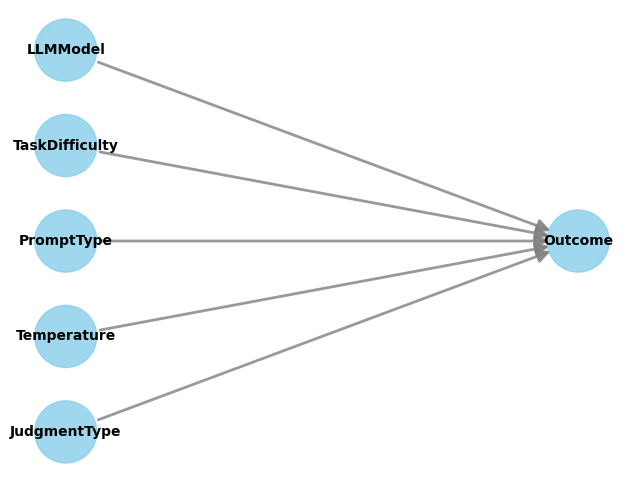

In [4]:
import dowhy
from dowhy import CausalModel

causal_graph = """
digraph {
    Temperature -> Outcome;
    JudgmentType -> Outcome;

    LLMModel -> Outcome;

    PromptType -> Outcome;

    TaskDifficulty -> Outcome;
}
"""


model = CausalModel(
    data=df,  # your dataframe
    treatment=["Temperature", "JudgmentType"],
    outcome="Agreement",  # or ConsistencyRate / BiasRate
    graph=causal_graph
)

model.view_model()  # renders the DAG using DoWhy's built-in viewer


In [ ]:

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import json

fig, ax = plt.subplots(figsize=(16, 11))
ax.set_xlim(0, 16)
ax.set_ylim(0, 11)
ax.axis('off')
ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')

# Temperature centered vertically in the middle column
nodes = {
    'LLMModel':        (2.5, 8.5),
    'PromptType':      (2.5, 5.5),
    'TaskDifficulty':  (2.5, 2.5),
    'Temperature':     (8.0, 5.5),   # CENTER of diagram
    'JudgmentType':    (8.0, 2.5),
    'Agreement':       (13.5, 8.5),
    'ConsistencyRate': (13.5, 5.5),
    'BiasRate':        (13.5, 2.5),
}

node_colors = {
    'LLMModel': '#e07b39', 'PromptType': '#e07b39', 'TaskDifficulty': '#e07b39',
    'Temperature': '#20a7db', 'JudgmentType': '#20a7db',
    'Agreement': '#4caf7d', 'ConsistencyRate': '#4caf7d', 'BiasRate': '#4caf7d',
}

node_labels = {
    'LLMModel': 'LLM Model', 'PromptType': 'Prompt Type',
    'TaskDifficulty': 'Task Difficulty\n/ Domain',
    'Temperature': 'Temperature', 'JudgmentType': 'Judgment Type',
    'Agreement': 'Agreement', 'ConsistencyRate': 'Consistency Rate', 'BiasRate': 'Bias Rate',
}

edges = [
    ('Temperature','Agreement','#20a7db'), ('Temperature','ConsistencyRate','#20a7db'), ('Temperature','BiasRate','#20a7db'),
    ('JudgmentType','Agreement','#20a7db'), ('JudgmentType','ConsistencyRate','#20a7db'), ('JudgmentType','BiasRate','#20a7db'),
    ('LLMModel','Temperature','#e07b39'), ('LLMModel','JudgmentType','#e07b39'),
    ('LLMModel','Agreement','#e07b39'), ('LLMModel','ConsistencyRate','#e07b39'), ('LLMModel','BiasRate','#e07b39'),
    ('PromptType','Temperature','#e07b39'), ('PromptType','JudgmentType','#e07b39'),
    ('PromptType','Agreement','#e07b39'), ('PromptType','ConsistencyRate','#e07b39'), ('PromptType','BiasRate','#e07b39'),
    ('TaskDifficulty','Temperature','#e07b39'), ('TaskDifficulty','JudgmentType','#e07b39'),
    ('TaskDifficulty','Agreement','#e07b39'), ('TaskDifficulty','ConsistencyRate','#e07b39'), ('TaskDifficulty','BiasRate','#e07b39'),
]

for src, dst, col in edges:
    x1, y1 = nodes[src]
    x2, y2 = nodes[dst]
    # Use slight curve to reduce overlap
    rad = 0.08 if src in ['LLMModel','PromptType','TaskDifficulty'] and dst in ['Agreement','ConsistencyRate','BiasRate'] else 0.03
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-|>", color=col, lw=1.4, alpha=0.5,
                        connectionstyle=f"arc3,rad={rad}"), zorder=2)

for name, (x, y) in nodes.items():
    label = node_labels[name]
    fs = 9.5 if name == 'TaskDifficulty' else 10.5
    # Make Temperature node slightly bigger to emphasize center role
    pad = 0.7 if name == 'Temperature' else 0.55
    lw = 2.5 if name == 'Temperature' else 1.8
    bbox = dict(boxstyle=f'round,pad={pad}', facecolor=node_colors[name],
                edgecolor='white', linewidth=lw, alpha=0.95)
    ax.text(x, y, label, ha='center', va='center', fontsize=fs,
            fontweight='bold', color='white', bbox=bbox, zorder=5)

# Column headers
for label, x in [('Confounders', 2.5), ('Treatments', 8.0), ('Outcomes', 13.5)]:
    ax.text(x, 10.2, label, ha='center', va='center', fontsize=12, color='#cccccc',
            fontstyle='italic',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffffff15', edgecolor='none'))

# Vertical dividers
for x in [5.2, 11.0]:
    ax.axvline(x, color='#444444', lw=1, linestyle='--', alpha=0.5)

# Annotation pointing to Temperature
ax.annotate('Central Treatment\n(focal node)', xy=(8.0, 5.5), xytext=(8.0, 7.8),
            ha='center', fontsize=8.5, color='#20a7db',
            arrowprops=dict(arrowstyle='->', color='#20a7db', lw=1.2, alpha=0.7),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#0d1117', edgecolor='#20a7db', alpha=0.8))

legend_items = [
    mpatches.Patch(color='#e07b39', label='Confounders'),
    mpatches.Patch(color='#20a7db', label='Treatments'),
    mpatches.Patch(color='#4caf7d', label='Outcomes'),
]
ax.legend(handles=legend_items, loc='lower center', ncol=3, fontsize=10,
          framealpha=0.3, labelcolor='white', facecolor='#1a1a2e',
          edgecolor='gray', bbox_to_anchor=(0.5, 0.01))

ax.set_title('Causal DAG: LLM Judgment Study  —  Temperature as Central Node',
             fontsize=13, fontweight='bold', color='white', pad=12)

plt.tight_layout()
plt.savefig('dag_temp_center.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.close()

with open('dag_temp_center.png.meta.json', 'w') as f:
    json.dump({
        "caption": "Causal DAG with Temperature centered as focal treatment node",
        "description": "DAG with Temperature placed at the vertical center of the diagram, highlighted as the focal treatment node."
    }, f)

print("Done")


Done
